In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')




In [2]:
df=pd.read_csv("loan aproval data.csv")

In [3]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [6]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')

In [7]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [8]:
df= df.drop('Applicant_ID',axis=1)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [11]:
df.isnull().sum()

Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [12]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()


In [13]:
numerical_cols

['Applicant_Income',
 'Coapplicant_Income',
 'Age',
 'Dependents',
 'Credit_Score',
 'Existing_Loans',
 'DTI_Ratio',
 'Savings',
 'Collateral_Value',
 'Loan_Amount',
 'Loan_Term']

In [14]:
categorical_cols=df.select_dtypes(include='object').columns.tolist()

In [15]:
categorical_cols

['Employment_Status',
 'Marital_Status',
 'Loan_Purpose',
 'Property_Area',
 'Education_Level',
 'Gender',
 'Employer_Category',
 'Loan_Approved']

In [16]:
if 'Loan_Approved' in categorical_cols:
    categorical_cols.remove('Loan_Approved')

In [17]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

In [18]:
for col in numerical_cols:
    df[col].fillna(df[col].median(),inplace=True)

In [19]:
df.isnull().sum()

Applicant_Income       0
Coapplicant_Income     0
Employment_Status      0
Age                    0
Marital_Status         0
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose           0
Property_Area          0
Education_Level        0
Gender                 0
Employer_Category      0
Loan_Approved         50
dtype: int64

In [20]:
df.shape

(1000, 19)

In [21]:
df=df.dropna(subset=['Loan_Approved'])

In [22]:
df.isnull().sum()

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    950 non-null    float64
 1   Coapplicant_Income  950 non-null    float64
 2   Employment_Status   950 non-null    object 
 3   Age                 950 non-null    float64
 4   Marital_Status      950 non-null    object 
 5   Dependents          950 non-null    float64
 6   Credit_Score        950 non-null    float64
 7   Existing_Loans      950 non-null    float64
 8   DTI_Ratio           950 non-null    float64
 9   Savings             950 non-null    float64
 10  Collateral_Value    950 non-null    float64
 11  Loan_Amount         950 non-null    float64
 12  Loan_Term           950 non-null    float64
 13  Loan_Purpose        950 non-null    object 
 14  Property_Area       950 non-null    object 
 15  Education_Level     950 non-null    object 
 16  Gender       

In [24]:
df.nunique()

Applicant_Income      880
Coapplicant_Income    858
Employment_Status       4
Age                    39
Marital_Status          2
Dependents              4
Credit_Score          246
Existing_Loans          5
DTI_Ratio              51
Savings               878
Collateral_Value      895
Loan_Amount           891
Loan_Term               7
Loan_Purpose            5
Property_Area           3
Education_Level         2
Gender                  2
Employer_Category       5
Loan_Approved           2
dtype: int64

In [25]:
df.shape

(950, 19)

In [26]:
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

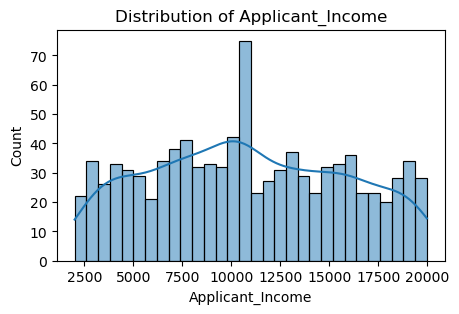

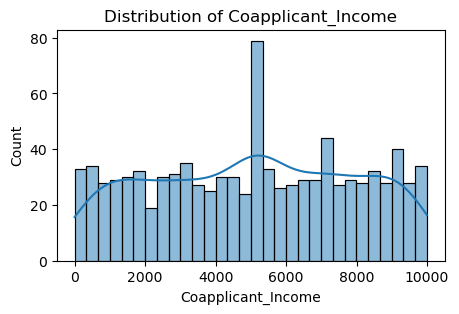

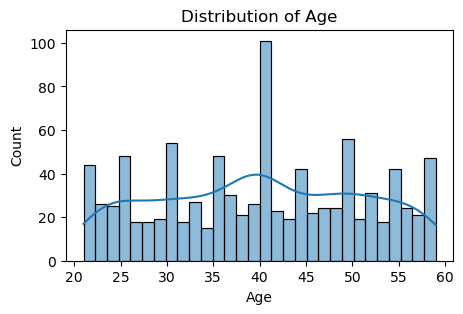

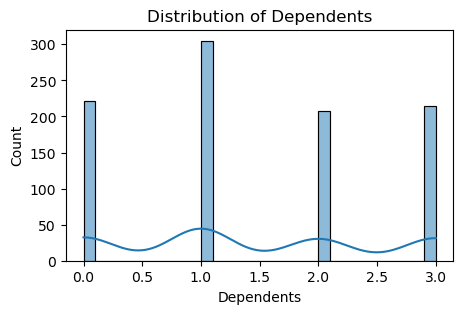

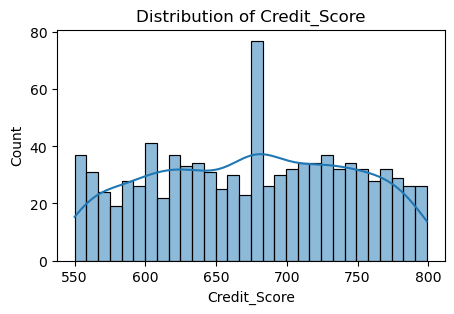

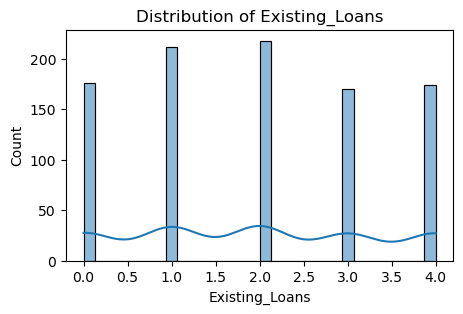

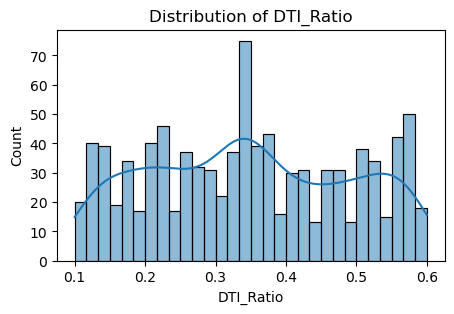

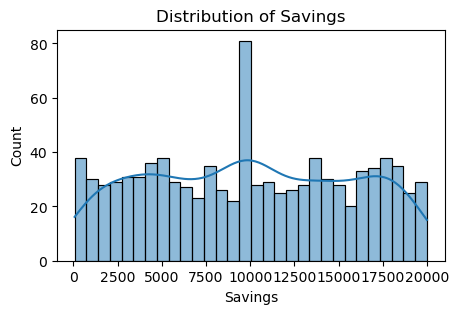

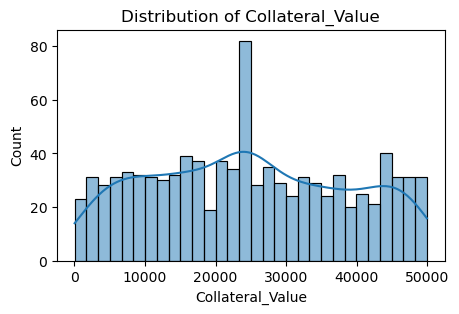

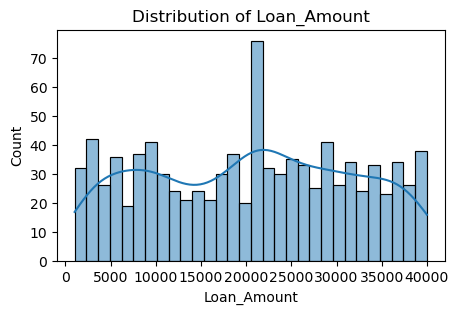

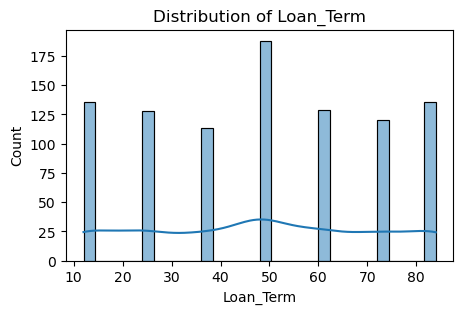

In [27]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(
        data=df[col],
        kde=True,
        bins=30
    )
    plt.title(f"Distribution of {col}")
    plt.show()

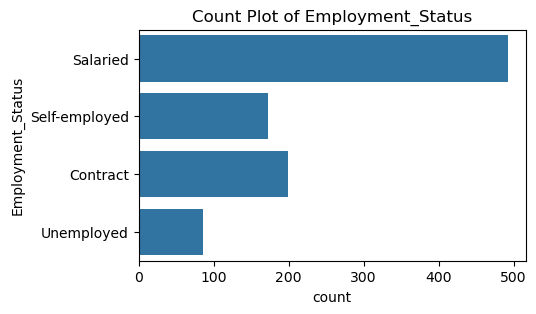

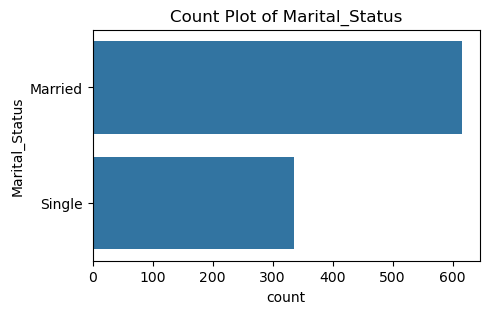

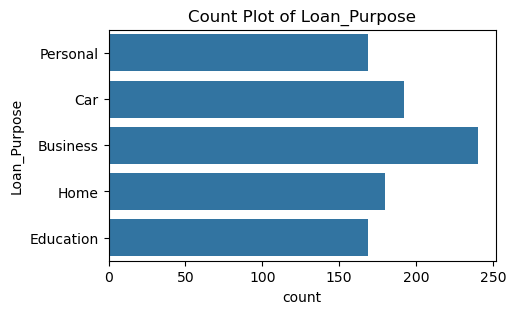

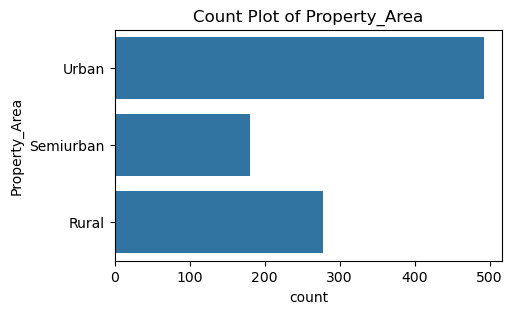

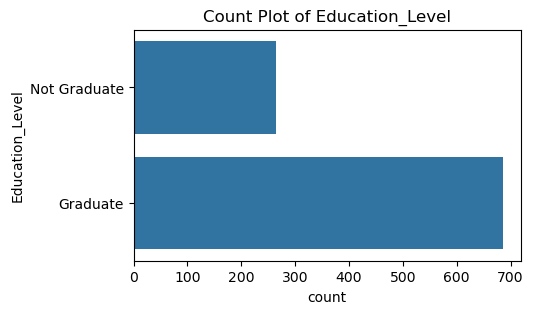

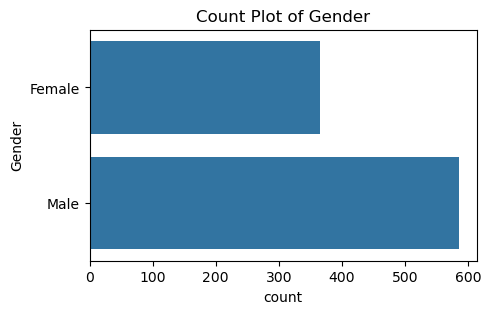

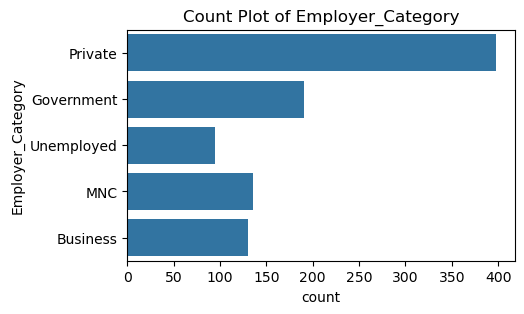

In [28]:
for col in categorical_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(
        data=df[col],
        

    )
    plt.title(f"Count Plot of {col}")
    plt.show()
    

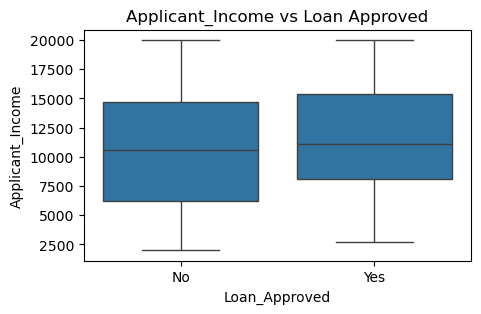

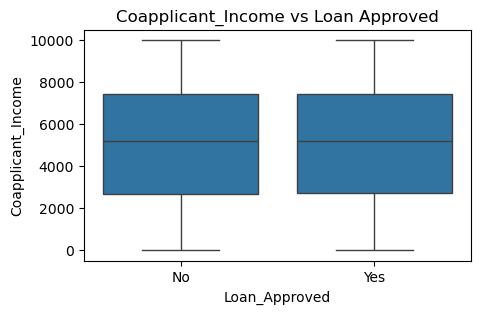

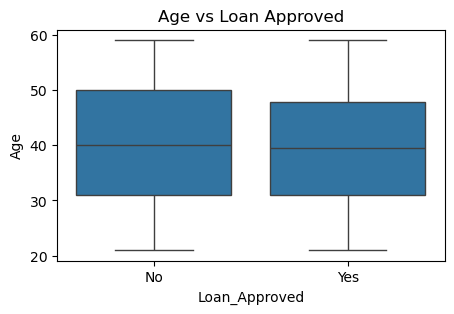

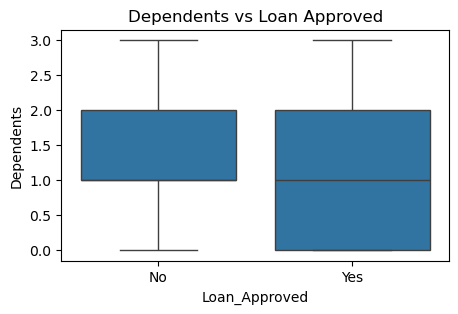

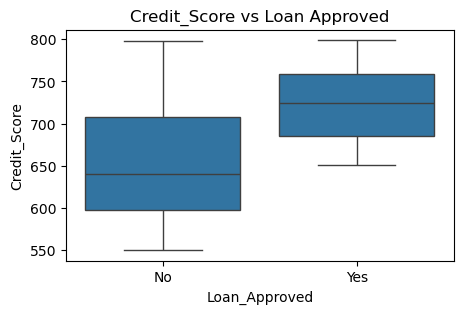

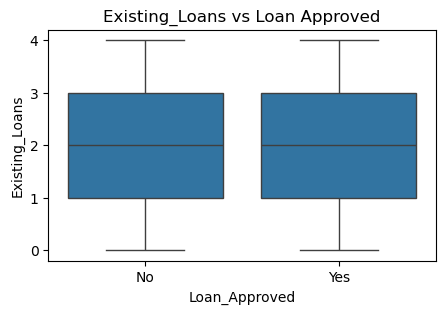

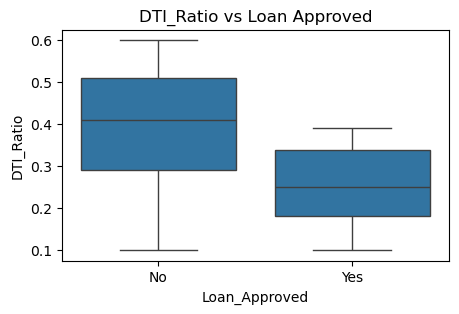

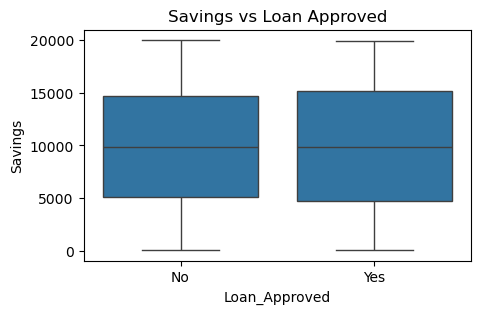

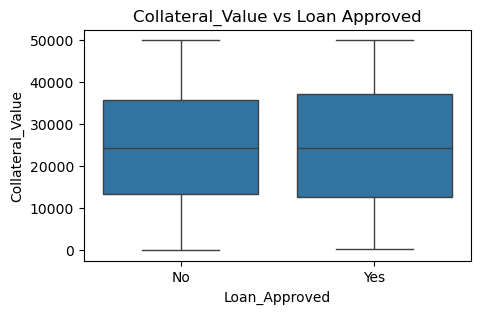

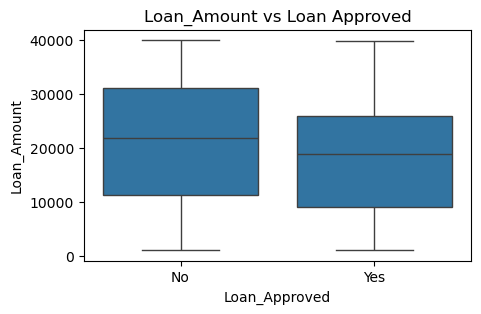

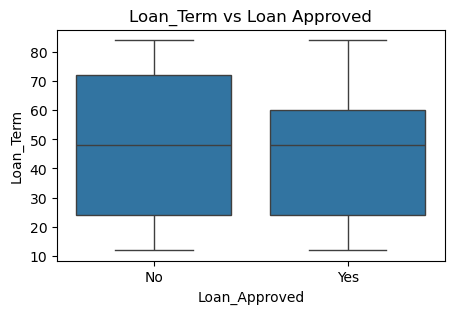

In [29]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(
        data=df,
        x="Loan_Approved",
        y=col

    )
    plt.title(f"{col} vs Loan Approved")
    plt.show()

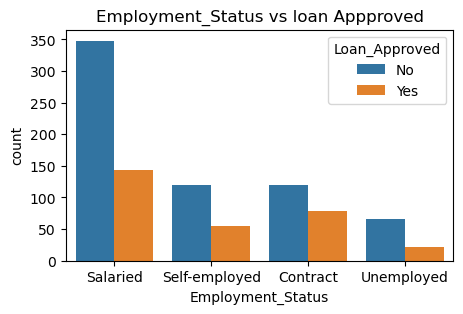

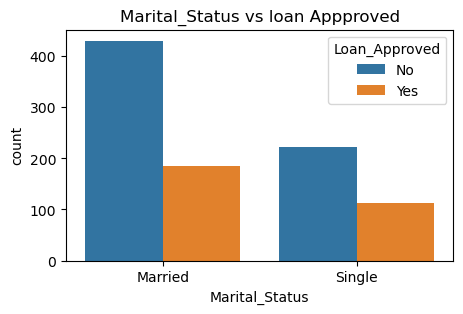

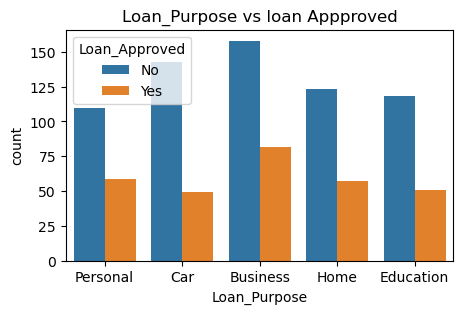

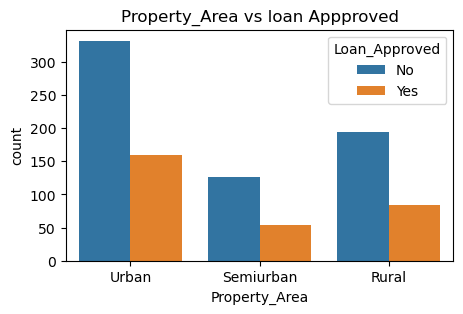

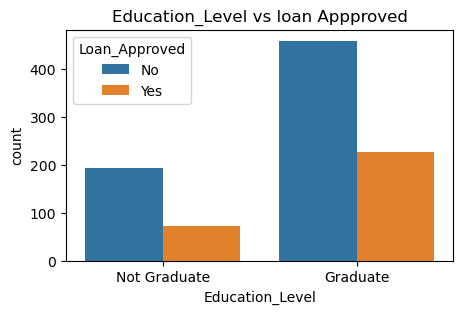

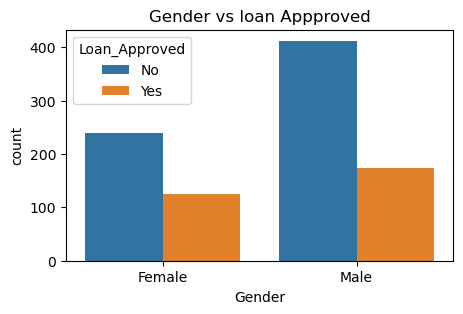

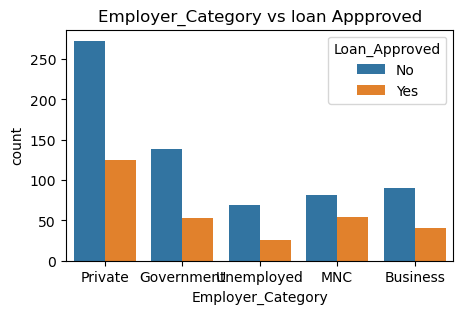

In [30]:
for col in categorical_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(
        data=df,
        x=col,
        hue="Loan_Approved"

    )
    plt.title(f"{col} vs loan Appproved")
    plt.show()

In [31]:
target=df['Loan_Approved'].map({
    'No':0,
    'Yes':1
    
})

In [32]:
correlation=df[numerical_cols].corrwith(target).sort_values(ascending=False)
correlation

Credit_Score          0.476980
Applicant_Income      0.125420
Collateral_Value      0.027248
Coapplicant_Income    0.008778
Dependents           -0.011539
Savings              -0.016878
Age                  -0.027374
Existing_Loans       -0.035753
Loan_Term            -0.089884
Loan_Amount          -0.127399
DTI_Ratio            -0.460487
dtype: float64

In [33]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Employment_Status
['Salaried' 'Self-employed' 'Contract' 'Unemployed']

Marital_Status
['Married' 'Single']

Loan_Purpose
['Personal' 'Car' 'Business' 'Home' 'Education']

Property_Area
['Urban' 'Semiurban' 'Rural']

Education_Level
['Not Graduate' 'Graduate']

Gender
['Female' 'Male']

Employer_Category
['Private' 'Government' 'Unemployed' 'MNC' 'Business']


In [34]:
X=df.drop('Loan_Approved',axis=1)
y=df['Loan_Approved'].map({
    'Yes':1,
    'No':0
})
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,stratify=y
)

In [35]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_cols),
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ]
)

In [36]:
lr_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])
lr_model.fit(X_train,y_train)
y_pred_lr=lr_model.predict(X_test)
print('Accuracy_lr:',accuracy_score(y_test,y_pred_lr))

print('\nClassification_Report_lr:')
print(classification_report(y_test,y_pred_lr))

print('\nConfusion_Matrix_lr:')
print(confusion_matrix(y_test,y_pred_lr))

Accuracy_lr: 0.868421052631579

Classification_Report_lr:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       130
           1       0.82      0.75      0.78        60

    accuracy                           0.87       190
   macro avg       0.85      0.84      0.84       190
weighted avg       0.87      0.87      0.87       190


Confusion_Matrix_lr:
[[120  10]
 [ 15  45]]


In [37]:
knn_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',KNeighborsClassifier(n_neighbors=3))
])
knn_model.fit(X_train,y_train)
y_pred_knn=knn_model.predict(X_test)
print('Accuracy_knn:',accuracy_score(y_test,y_pred_knn))

print('\nClassification_Report_knn:')
print(classification_report(y_test,y_pred_knn))

print('\nConfusion_Matrix_knn:')
print(confusion_matrix(y_test,y_pred_knn))

Accuracy_knn: 0.7736842105263158

Classification_Report_knn:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       130
           1       0.63      0.67      0.65        60

    accuracy                           0.77       190
   macro avg       0.74      0.74      0.74       190
weighted avg       0.78      0.77      0.78       190


Confusion_Matrix_knn:
[[107  23]
 [ 20  40]]


In [38]:
gb_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',GradientBoostingClassifier())
])
gb_model.fit(X_train,y_train)
y_pred_gb=gb_model.predict(X_test)
print('Accuracy_gb:',accuracy_score(y_test,y_pred_gb))

print('\nClassification_Report_gb:')
print(classification_report(y_test,y_pred_gb))

print('\nConfusion_Matrix_gb:')
print(confusion_matrix(y_test,y_pred_gb))

Accuracy_gb: 0.9578947368421052

Classification_Report_gb:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       130
           1       0.91      0.97      0.94        60

    accuracy                           0.96       190
   macro avg       0.95      0.96      0.95       190
weighted avg       0.96      0.96      0.96       190


Confusion_Matrix_gb:
[[124   6]
 [  2  58]]


In [39]:
svc_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',SVC(kernel='rbf'))
])
svc_model.fit(X_train,y_train)
y_pred_svc=svc_model.predict(X_test)
print('Accuracy_svc:',accuracy_score(y_test,y_pred_svc))

print('\nClassification_Report_svc:')
print(classification_report(y_test,y_pred_svc))

print('\nConfusion_Matrix_svc:')
print(confusion_matrix(y_test,y_pred_svc))

Accuracy_svc: 0.8947368421052632

Classification_Report_svc:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       130
           1       0.87      0.78      0.82        60

    accuracy                           0.89       190
   macro avg       0.89      0.86      0.87       190
weighted avg       0.89      0.89      0.89       190


Confusion_Matrix_svc:
[[123   7]
 [ 13  47]]


In [40]:
dt_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',DecisionTreeClassifier())
])
dt_model.fit(X_train,y_train)
y_pred_dt=lr_model.predict(X_test)
print('Accuracy_dt:',accuracy_score(y_test,y_pred_dt))

print('\nClassification_Report_dt:')
print(classification_report(y_test,y_pred_dt))

print('\nConfusion_Matrix_dt:')
print(confusion_matrix(y_test,y_pred_dt))

Accuracy_dt: 0.868421052631579

Classification_Report_dt:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       130
           1       0.82      0.75      0.78        60

    accuracy                           0.87       190
   macro avg       0.85      0.84      0.84       190
weighted avg       0.87      0.87      0.87       190


Confusion_Matrix_dt:
[[120  10]
 [ 15  45]]


In [41]:
rf_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(max_depth=3))
])
rf_model.fit(X_train,y_train)
y_pred_rf=lr_model.predict(X_test)
print('Accuracy_rf:',accuracy_score(y_test,y_pred_rf))

print('\nClassification_Report_rf:')
print(classification_report(y_test,y_pred_rf))

print('\nConfusion_Matrix_rf:')
print(confusion_matrix(y_test,y_pred_rf))

Accuracy_rf: 0.868421052631579

Classification_Report_rf:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       130
           1       0.82      0.75      0.78        60

    accuracy                           0.87       190
   macro avg       0.85      0.84      0.84       190
weighted avg       0.87      0.87      0.87       190


Confusion_Matrix_rf:
[[120  10]
 [ 15  45]]


In [42]:
xgb_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBClassifier(max_depth=5))
])
xgb_model.fit(X_train,y_train)
y_pred_xgb=xgb_model.predict(X_test)
print('Accuracy_xgb:',accuracy_score(y_test,y_pred_xgb))

print('\nClassification_Report_xgb:')
print(classification_report(y_test,y_pred_xgb))

print('\nConfusion_Matrix_xgb:')
print(confusion_matrix(y_test,y_pred_xgb))

Accuracy_xgb: 0.9578947368421052

Classification_Report_xgb:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       130
           1       0.92      0.95      0.93        60

    accuracy                           0.96       190
   macro avg       0.95      0.96      0.95       190
weighted avg       0.96      0.96      0.96       190


Confusion_Matrix_xgb:
[[125   5]
 [  3  57]]


In [43]:
AdaBoost_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',AdaBoostClassifier())
])
AdaBoost_model.fit(X_train,y_train)
y_pred_AdaBoost=AdaBoost_model.predict(X_test)
print('Accuracy_Adaboost:',accuracy_score(y_test,y_pred_AdaBoost))

print('\nClassification_Report_AdaBoost:')
print(classification_report(y_test,y_pred_AdaBoost))

print('\nConfusion_Matrix_Adaboost:')
print(confusion_matrix(y_test,y_pred_AdaBoost))

Accuracy_Adaboost: 0.9421052631578948

Classification_Report_AdaBoost:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       130
           1       0.87      0.97      0.91        60

    accuracy                           0.94       190
   macro avg       0.92      0.95      0.93       190
weighted avg       0.95      0.94      0.94       190


Confusion_Matrix_Adaboost:
[[121   9]
 [  2  58]]


In [44]:
from sklearn.model_selection import cross_val_score
cv_score=cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)
print('CV Score',cv_score)
print('Mean CV Accuracy',cv_score.mean())


CV Score [0.95394737 0.96052632 0.97368421 0.97368421 0.93421053]
Mean CV Accuracy 0.9592105263157895


In [47]:
new_data = pd.DataFrame([{
    'Applicant_Income': 50,
    'Coapplicant_Income': 20000,
    'Marital_Status': 'Married',
    'Dependents': 2,
    'Credit_Score': 750,
    'Existing_Loans': 1,
    'Age': 32,
    'DTI_Ratio': 0.30,
    'Savings': 100000,
    'Collateral_Value': 5,
    'Loan_Amount': 200000,
    'Loan_Term': 360,
    'Loan_Purpose': 'Home',
    'Property_Area': 'Urban',
    'Education_Level': 'Graduate',
    'Gender': 'Male',
    'Employment_Status': 'Salaried',
    'Employer_Category': 'Private'
}])

prediction = xgb_model.predict(new_data)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

Loan Not Approved


In [48]:
import joblib
joblib.dump(xgb_model,'loan_xgb_model.pkl')

['loan_xgb_model.pkl']

In [49]:
loan_features=X.columns.tolist()
joblib.dump(loan_features,'loan_features.pkl')

['loan_features.pkl']